# 02 — Explore OCHA FTS Data

**OCHA Financial Tracking Service** records every reported grant and contribution flowing into humanitarian crises worldwide.

This notebook answers:
1. How much has the US contributed to humanitarian response each year?
2. How do US amounts compare to other major donors?
3. Which crisis countries receive the most? Which sectors?
4. Are there signs of other donors filling in as US funding falls?

Data: `data/raw/fts_flows_2018_2025.csv` — produced by `src/fetch_fts.py`

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
# Works whether run as notebook (parent = notebooks/) or executed via nbconvert
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_FILE = PROJECT_ROOT / "data" / "raw" / "fts_flows_2018_2025.csv"
CHART_DIR = PROJECT_ROOT / "output" / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data file:    {DATA_FILE}  (exists: {DATA_FILE.exists()})")

Project root: /Users/pauldelor/Documents/Rebelga/who-fills-the-gap
Data file:    /Users/pauldelor/Documents/Rebelga/who-fills-the-gap/data/raw/fts_flows_2018_2025.csv  (exists: True)


In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_FILE, dtype={"flow_id": str}, low_memory=False)

# Parse the date field; keep original on failure
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Normalise amount: treat NaN or negative as 0 for aggregation
df["amount_usd"] = pd.to_numeric(df["amount_usd"], errors="coerce").fillna(0)

# query_year is the year we used when calling the API — use it as primary year
# because budget_year and usage_year have many nulls.
df["year"] = df["query_year"].astype(int)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")

Shape: 218,558 rows × 16 columns

Columns:
['flow_id', 'amount_usd', 'budget_year', 'usage_year', 'status', 'flow_type', 'contribution_type', 'method', 'date', 'source_org', 'source_country', 'dest_org', 'dest_country', 'cluster', 'query_year', 'year']

Dtypes:
flow_id                           object
amount_usd                         int64
budget_year                      float64
usage_year                       float64
status                            object
flow_type                         object
contribution_type                 object
method                            object
date                 datetime64[ns, UTC]
source_org                        object
source_country                    object
dest_org                          object
dest_country                      object
cluster                           object
query_year                         int64
year                               int64
dtype: object

Null counts:
flow_id                  0
amount_usd               0


## 1 — Year-by-year overview

In [3]:
# Rows and total USD by year — high-level sanity check
by_year = (
    df.groupby("year")
    .agg(flow_count=("flow_id", "count"), total_usd=("amount_usd", "sum"))
    .reset_index()
)
by_year["total_bn"] = by_year["total_usd"] / 1e9
print(by_year.to_string(index=False))
print(f"\nGrand total: ${by_year['total_bn'].sum():.1f} billion across {by_year['flow_count'].sum():,} flows")

 year  flow_count   total_usd  total_bn
 2018       18086 34886350777 34.886351
 2019       19330 34455394222 34.455394
 2020       23777 38177043129 38.177043
 2021       24542 43149488350 43.149488
 2022       29134 53705053544 53.705054
 2023       34895 47776149078 47.776149
 2024       36293 44507718954 44.507719
 2025       32501 32475971978 32.475972

Grand total: $329.1 billion across 218,558 flows


## 2 — US vs all-other donors by year

The US government has historically been the largest single humanitarian donor.
Here we isolate flows whose source organisation contains "United States" to track
the trajectory of US humanitarian giving — and compare it to the rest of the world.

**Note:** FTS records the *reporting* organisation, which for US government flows
is typically "United States of America, Government of" or the specific agency
(USAID, State Dept, etc.). We'll capture all of them with a partial-string match.

In [4]:
# Find all distinct source org names that include "United States"
us_orgs = df["source_org"].dropna().unique()
us_orgs = sorted([o for o in us_orgs if "United States" in str(o)])
print(f"US-related source orgs ({len(us_orgs)}):\n")
for o in us_orgs:
    print(f"  {o}")

US-related source orgs (4):

  United States Agency for International Development
  United States Department of State
  United States Fund for UNICEF
  United States of America, Government of


In [5]:
# Flag US flows; everything else is "Other donors"
df["is_us"] = df["source_org"].str.contains("United States", na=False)

# Aggregate by year and donor group
by_year_group = (
    df.groupby(["year", "is_us"])["amount_usd"]
    .sum()
    .unstack(fill_value=0)
    .rename(columns={True: "US", False: "Other donors"})
    .assign(Total=lambda x: x["US"] + x["Other donors"])
)
by_year_group["US_pct"] = (by_year_group["US"] / by_year_group["Total"] * 100).round(1)

print(by_year_group.assign(
    US_bn=lambda x: x["US"] / 1e9,
    Other_bn=lambda x: x["Other donors"] / 1e9,
    Total_bn=lambda x: x["Total"] / 1e9,
)[["US_bn", "Other_bn", "Total_bn", "US_pct"]].to_string())

print("\n(amounts in $B)")

is_us      US_bn   Other_bn   Total_bn  US_pct
year                                          
2018    7.745183  27.141168  34.886351    22.2
2019    8.907800  25.547594  34.455394    25.9
2020    9.653290  28.523753  38.177043    25.3
2021   11.643906  31.505582  43.149488    27.0
2022   18.450644  35.254410  53.705054    34.4
2023   15.256418  32.519731  47.776149    31.9
2024   14.789746  29.717973  44.507719    33.2
2025    4.158178  28.317794  32.475972    12.8

(amounts in $B)


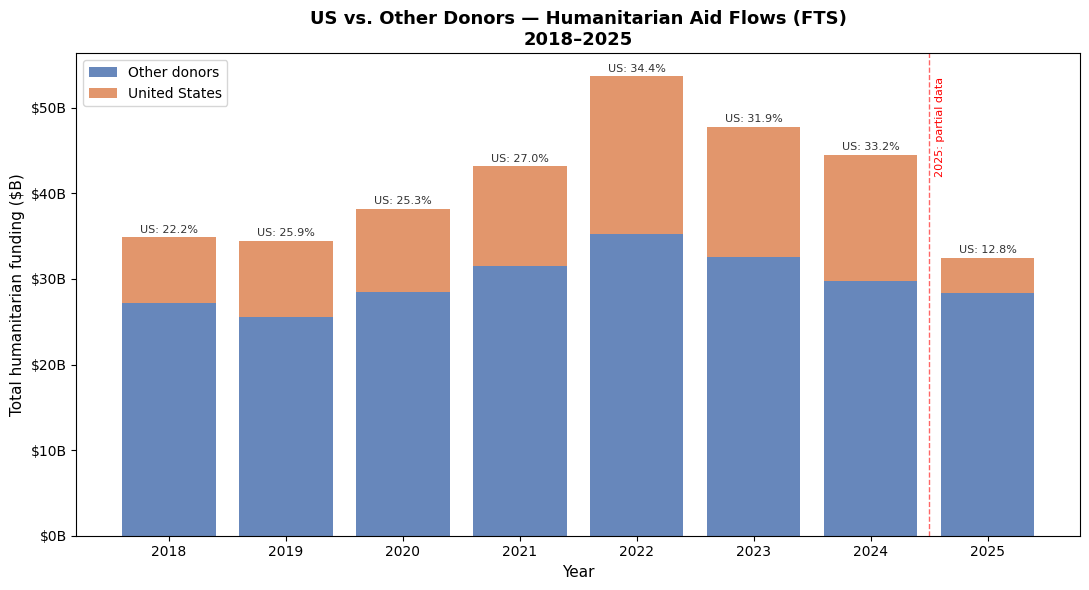

Saved → /Users/pauldelor/Documents/Rebelga/who-fills-the-gap/output/charts/fts_us_vs_others_by_year.png


In [6]:
# ── Chart: Stacked bar — US vs other donors 2018–2025 ────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

years = by_year_group.index
us_bn = by_year_group["US"] / 1e9
other_bn = by_year_group["Other donors"] / 1e9

bars_other = ax.bar(years, other_bn, label="Other donors", color="#4C72B0", alpha=0.85)
bars_us = ax.bar(years, us_bn, bottom=other_bn, label="United States", color="#DD8452", alpha=0.85)

# Annotate US share on each bar
for yr, us_val, oth_val, pct in zip(years, us_bn, other_bn, by_year_group["US_pct"]):
    ax.text(yr, us_val + oth_val + 0.3, f"US: {pct}%",
            ha="center", va="bottom", fontsize=8, color="#333333")

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Total humanitarian funding ($B)", fontsize=11)
ax.set_title("US vs. Other Donors — Humanitarian Aid Flows (FTS)\n2018–2025",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.set_xticks(years)

# Mark 2025 as partial data
ax.axvline(2024.5, color="red", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2024.55, ax.get_ylim()[1] * 0.95, "2025: partial data",
        fontsize=8, color="red", rotation=90, va="top")

plt.tight_layout()
chart_path = CHART_DIR / "fts_us_vs_others_by_year.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {chart_path}")

## 3 — Top donors 2023 vs 2024 (most recent comparable years)

In [7]:
# Top 15 source orgs in 2023 and 2024
for yr in [2023, 2024]:
    top = (
        df[df["year"] == yr]
        .groupby("source_org")["amount_usd"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
        / 1e9
    )
    print(f"\n── Top 15 donors {yr} ($ billion) ──")
    for org, val in top.items():
        print(f"  {val:6.2f}B   {org}")


── Top 15 donors 2023 ($ billion) ──
   11.21B   United States of America, Government of
    5.09B   Germany, Government of
    3.98B   United States Department of State
    3.97B   European Commission's Humanitarian Aid and Civil Protection Department
    2.14B   Saudi Arabia (Kingdom of), Government of
    1.56B   United Kingdom, Government of
    1.51B   Japan, Government of
    1.21B   Norway, Government of
    1.21B   Sweden, Government of
    1.06B   Netherlands, Government of
    0.97B   United Arab Emirates, Government of
    0.94B   France, Government of
    0.93B   Switzerland, Government of
    0.84B   Canada, Government of
    0.75B   Central Emergency Response Fund

── Top 15 donors 2024 ($ billion) ──
   10.38B   United States of America, Government of
    4.37B   United States Department of State
    3.82B   European Commission's Humanitarian Aid and Civil Protection Department
    3.18B   Germany, Government of
    2.70B   United Kingdom, Government of
    2.15B   Japa

## 4 — Top recipient countries

In [8]:
# Top 10 destination countries by total funding 2018–2025
top_countries = (
    df.groupby("dest_country")["amount_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    / 1e9
)
print("Top 10 recipient countries — all years combined ($ billion):")
print(top_countries.to_string())

# 2024 specifically
print("\nTop 10 recipient countries — 2024 only ($ billion):")
print(
    df[df["year"] == 2024]
    .groupby("dest_country")["amount_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .div(1e9)
    .to_string()
)

Top 10 recipient countries — all years combined ($ billion):
dest_country
Syrian Arab Republic              29.291447
Yemen                             29.139368
Global                            21.293411
Ukraine                           17.050796
Afghanistan                       16.096983
Occupied Palestinian Territory    15.418879
South Sudan                       13.772618
Lebanon                           13.702227
Ethiopia                          13.324867
Somalia                           13.127289

Top 10 recipient countries — 2024 only ($ billion):
dest_country
Global                              4.300061
Occupied Palestinian Territory      4.185254
Ukraine                             3.430709
Yemen                               2.991622
Sudan                               2.513684
Syrian Arab Republic                2.435520
Afghanistan                         2.011471
South Sudan                         1.916285
Ethiopia                            1.672341
Democratic Repu

## 5 — Humanitarian sectors (GlobalCluster breakdown)

In [9]:
# Cluster coverage — roughly 30% of flows have a GlobalCluster tag
cluster_coverage = df["cluster"].notna().mean() * 100
print(f"Flows with GlobalCluster tag: {cluster_coverage:.1f}%\n")

# Top clusters by funding
top_clusters = (
    df.dropna(subset=["cluster"])
    .groupby("cluster")["amount_usd"]
    .sum()
    .sort_values(ascending=False)
    / 1e9
)
print("Funding by GlobalCluster — all years ($ billion):")
print(top_clusters.to_string())

Flows with GlobalCluster tag: 80.0%



Funding by GlobalCluster — all years ($ billion):
cluster
Food Security                                 77.032619
Health                                        32.767212
Multi-sector                                  26.268285
Protection                                    16.069977
Water Sanitation Hygiene                      14.510645
Education                                     13.942811
Nutrition                                     13.739917
Emergency Shelter and NFI                     13.487499
Coordination and support services             13.292118
Logistics                                      6.282272
Early Recovery                                 6.249919
Multipurpose Cash                              5.810693
Other                                          4.029709
Protection - Child Protection                  3.883790
Protection - Gender-Based Violence             3.193010
Protection - Mine Action                       2.209626
COVID-19                                      

## 6 — Early signal: US 2025 vs 2024 (partial year comparison)

2025 data in FTS is still being reported. We can compare Jan–May 2025 vs Jan–May 2024
to get an early read on whether US humanitarian funding has dropped after the executive
order freeze in January 2025. Use with caution — reporting lags mean 2025 will be
undercounted relative to 2024 at the same calendar point.

In [10]:
import datetime

today = datetime.date.today()
cutoff_2024 = f"2024-{today.month:02d}-{today.day:02d}"
cutoff_2025 = f"2025-{today.month:02d}-{today.day:02d}"

df_dated = df[df["date"].notna()].copy()

# FTS dates are UTC-timezone-aware; make our cutoff timestamps match.
ts_2024 = pd.Timestamp(cutoff_2024, tz="UTC")
ts_2025 = pd.Timestamp(cutoff_2025, tz="UTC")

# Ensure date column is tz-aware (it may be tz-naive if loaded from CSV)
if df_dated["date"].dt.tz is None:
    df_dated["date"] = df_dated["date"].dt.tz_localize("UTC")

def ytd_us(year: int, cutoff: pd.Timestamp) -> float:
    mask = (
        (df_dated["year"] == year)
        & df_dated["is_us"]
        & (df_dated["date"] <= cutoff)
    )
    return df_dated.loc[mask, "amount_usd"].sum()

def ytd_all(year: int, cutoff: pd.Timestamp) -> float:
    mask = (
        (df_dated["year"] == year)
        & (df_dated["date"] <= cutoff)
    )
    return df_dated.loc[mask, "amount_usd"].sum()

us_2024 = ytd_us(2024, ts_2024)
us_2025 = ytd_us(2025, ts_2025)
all_2024 = ytd_all(2024, ts_2024)
all_2025 = ytd_all(2025, ts_2025)

print(f"Year-to-date comparison (through {today.strftime('%B %d')}):")
print(f"\n  US humanitarian funding:")
print(f"    2024 YTD: ${us_2024/1e9:.2f}B")
print(f"    2025 YTD: ${us_2025/1e9:.2f}B")
if us_2024 > 0:
    print(f"    Change:   {(us_2025 - us_2024) / us_2024 * 100:+.1f}%")
print(f"\n  Total all donors:")
print(f"    2024 YTD: ${all_2024/1e9:.2f}B")
print(f"    2025 YTD: ${all_2025/1e9:.2f}B")
if all_2024 > 0:
    print(f"    Change:   {(all_2025 - all_2024) / all_2024 * 100:+.1f}%")
print(f"\n⚠️  2025 data is partial — reporting lags mean flows are still being added.")

Year-to-date comparison (through May 08):

  US humanitarian funding:
    2024 YTD: $4.39B
    2025 YTD: $1.65B
    Change:   -62.3%

  Total all donors:
    2024 YTD: $14.61B
    2025 YTD: $8.19B
    Change:   -44.0%

⚠️  2025 data is partial — reporting lags mean flows are still being added.


## 7 — Flags and data quality notes

In [11]:
print("=== DATA QUALITY FLAGS ===\n")

# 1. Flows with zero or null amounts
zero_or_null = (df["amount_usd"] == 0).sum()
print(f"1. Flows with $0 amount: {zero_or_null:,} ({zero_or_null/len(df)*100:.1f}%)")
print("   → These are often 'in-kind' or 'parked' flows awaiting allocation.\n")

# 2. Null source org (anonymous or unattributed donors)
null_src = df["source_org"].isna().sum()
print(f"2. Flows with no source org: {null_src:,} ({null_src/len(df)*100:.1f}%)")
print("   → May be pooled funds (CERF, etc.) or confidential donors.\n")

# 3. Null destination country (multilateral/global flows)
null_dst = df["dest_country"].isna().sum()
print(f"3. Flows with no destination country: {null_dst:,} ({null_dst/len(df)*100:.1f}%)")
print("   → Usually contributions to global pooled funds (not country-specific).\n")

# 4. Flow status breakdown
print("4. Flow status breakdown:")
print(df["status"].value_counts().to_string())
print("   → We'll use both 'commitment' and 'paid' in analysis (standard FTS practice).\n")

# 5. Contribution types
print("5. Contribution type breakdown:")
print(df["contribution_type"].value_counts().to_string())
print("   → We focus on 'financial' flows; in-kind have inconsistent USD valuations.")

=== DATA QUALITY FLAGS ===

1. Flows with $0 amount: 12,574 (5.8%)
   → These are often 'in-kind' or 'parked' flows awaiting allocation.

2. Flows with no source org: 1,320 (0.6%)
   → May be pooled funds (CERF, etc.) or confidential donors.

3. Flows with no destination country: 7,732 (3.5%)
   → Usually contributions to global pooled funds (not country-specific).

4. Flow status breakdown:
status
paid          133137
commitment     84912
pledge           509
   → We'll use both 'commitment' and 'paid' in analysis (standard FTS practice).

5. Contribution type breakdown:
contribution_type
financial    212227
in kind        6315
   → We focus on 'financial' flows; in-kind have inconsistent USD valuations.


## 8 — Where does US money go? (destination country breakdown)

Understanding which countries depend most heavily on US humanitarian funding tells us
where the withdrawal will hurt most. A country receiving 40% of its international
humanitarian aid from the US is far more exposed than one receiving 5%.

We compute, for the most recent full year (2024), each country's total humanitarian
inflows and the US share within that.

In [12]:
df_2024 = df[(df["year"] == 2024) & df["dest_country"].notna()].copy()

# Total inflows per country from ALL donors
country_total = (
    df_2024.groupby("dest_country")["amount_usd"].sum().rename("total_usd")
)

# Inflows per country from the US only
country_us = (
    df_2024[df_2024["is_us"]]
    .groupby("dest_country")["amount_usd"]
    .sum()
    .rename("us_usd")
)

country_dep = (
    pd.concat([country_total, country_us], axis=1)
    .fillna(0)
    .assign(us_pct=lambda x: (x["us_usd"] / x["total_usd"] * 100).round(1))
    .sort_values("total_usd", ascending=False)
)

# Show top 20 by total inflows, with US share
print("Top 20 humanitarian recipient countries in 2024 (by total funding):")
print(f"{'Country':<35} {'Total ($M)':>12} {'US ($M)':>12} {'US share':>10}")
print("-" * 72)
for country, row in country_dep.head(20).iterrows():
    print(f"{country:<35} {row['total_usd']/1e6:>12,.0f} {row['us_usd']/1e6:>12,.0f} {row['us_pct']:>9.1f}%")

Top 20 humanitarian recipient countries in 2024 (by total funding):
Country                               Total ($M)      US ($M)   US share
------------------------------------------------------------------------
Global                                     4,300        1,055      24.5%
Occupied Palestinian Territory             4,185          866      20.7%
Ukraine                                    3,431          705      20.6%
Yemen                                      2,992          809      27.0%
Sudan                                      2,514          960      38.2%
Syrian Arab Republic                       2,436          462      19.0%
Afghanistan                                2,011          775      38.5%
South Sudan                                1,916          714      37.3%
Ethiopia                                   1,672          558      33.4%
Democratic Republic of the Congo           1,632          981      60.1%
Lebanon                                    1,559        

In [13]:
# Countries most DEPENDENT on the US (high US share, meaningful total inflows)
# Use a floor of $10M total to exclude tiny flows that skew percentages.
MIN_TOTAL = 10e6

high_dependency = (
    country_dep[country_dep["total_usd"] >= MIN_TOTAL]
    .sort_values("us_pct", ascending=False)
    .head(15)
)

print("Countries most dependent on US humanitarian funding (2024):")
print(f"  (minimum $10M total inflows from all donors)\n")
print(f"{'Country':<35} {'Total ($M)':>12} {'US ($M)':>12} {'US share':>10}")
print("-" * 72)
for country, row in high_dependency.iterrows():
    flag = " ← HIGH EXPOSURE" if row["us_pct"] > 40 else ""
    print(f"{country:<35} {row['total_usd']/1e6:>12,.0f} {row['us_usd']/1e6:>12,.0f} {row['us_pct']:>9.1f}%{flag}")

Countries most dependent on US humanitarian funding (2024):
  (minimum $10M total inflows from all donors)

Country                               Total ($M)      US ($M)   US share
------------------------------------------------------------------------
Region - Europe                              101           99      98.2% ← HIGH EXPOSURE
Region - Southern and Eastern Africa          105          103      97.3% ← HIGH EXPOSURE
Region - Asia and the Pacific                 72           69      95.4% ← HIGH EXPOSURE
Region - Middle East and Northern Africa          536          502      93.6% ← HIGH EXPOSURE
Costa Rica                                    25           23      91.2% ← HIGH EXPOSURE
Fiji                                          11            9      86.6% ← HIGH EXPOSURE
Mexico                                       112           96      85.4% ← HIGH EXPOSURE
Region - Latin America and the Caribbean           69           58      84.3% ← HIGH EXPOSURE
Thailand               

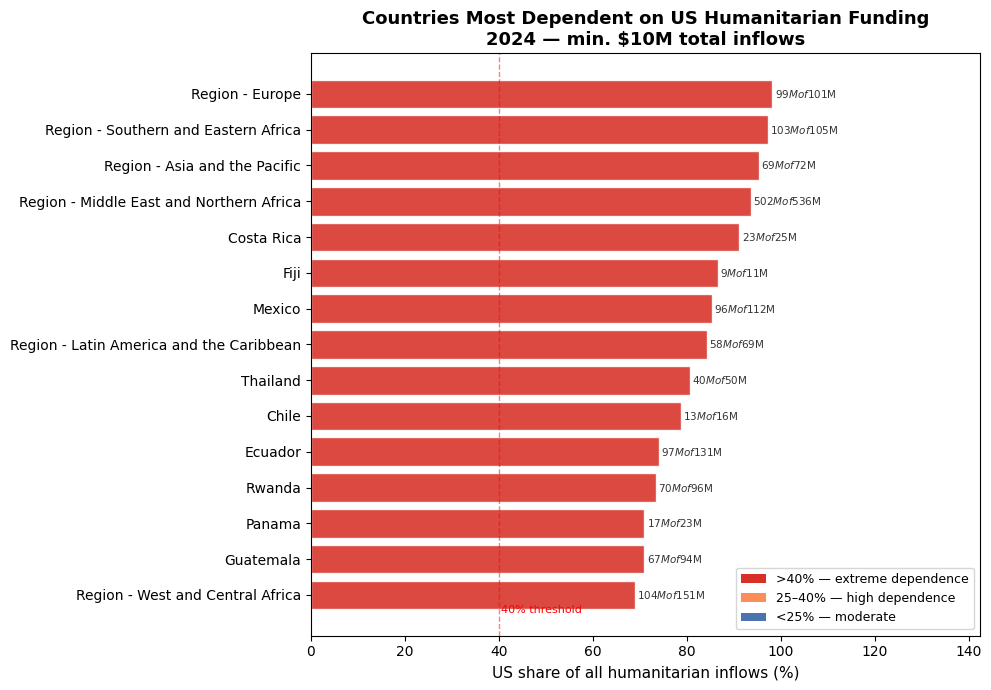

Saved → /Users/pauldelor/Documents/Rebelga/who-fills-the-gap/output/charts/fts_country_us_dependency_2024.png


In [14]:
# ── Chart: horizontal bar — top 15 countries by US dependency ────────────────
fig, ax = plt.subplots(figsize=(10, 7))

plot_data = high_dependency.sort_values("us_pct")
colors = ["#d73027" if v > 40 else "#fc8d59" if v > 25 else "#4C72B0"
          for v in plot_data["us_pct"]]

bars = ax.barh(plot_data.index, plot_data["us_pct"], color=colors, alpha=0.88, edgecolor="white")

# Add dollar amounts as text inside bars
for bar, (_, row) in zip(bars, plot_data.iterrows()):
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
            f"${row['us_usd']/1e6:.0f}M of ${row['total_usd']/1e6:.0f}M",
            va="center", fontsize=7.5, color="#333333")

ax.set_xlabel("US share of all humanitarian inflows (%)", fontsize=11)
ax.set_title(
    "Countries Most Dependent on US Humanitarian Funding\n"
    "2024 — min. $10M total inflows",
    fontsize=13, fontweight="bold"
)
ax.axvline(40, color="red", linestyle="--", linewidth=1, alpha=0.5)
ax.text(40.5, -0.5, "40% threshold", color="red", fontsize=8)
ax.set_xlim(0, max(plot_data["us_pct"]) * 1.45)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d73027", label=">40% — extreme dependence"),
    Patch(facecolor="#fc8d59", label="25–40% — high dependence"),
    Patch(facecolor="#4C72B0", label="<25% — moderate"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
chart_path = CHART_DIR / "fts_country_us_dependency_2024.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {chart_path}")

## 9 — Who receives US money? (destination organisations)

Beyond countries, FTS tells us *which organisations* the US funds. This matters because
USAID and State Dept typically channel money through UN agencies (WFP, UNICEF, UNHCR)
and large international NGOs — not directly to governments. Understanding which
implementing organisations are exposed helps predict where programmatic gaps will appear.

In [15]:
df_us_2024 = df[(df["year"] == 2024) & df["is_us"] & df["dest_org"].notna()]

top_us_recipients = (
    df_us_2024.groupby("dest_org")["amount_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

print("Top 20 organisations receiving US humanitarian funding in 2024:\n")
print(f"{'Organisation':<55} {'US funding ($M)':>16}")
print("-" * 73)
for org, val in top_us_recipients.items():
    print(f"{org:<55} {val/1e6:>15,.1f}")

print(f"\nTotal to top 20: ${top_us_recipients.sum()/1e9:.2f}B")
print(f"Total US 2024:   ${df_us_2024['amount_usd'].sum()/1e9:.2f}B")
print(f"Top 20 share:    {top_us_recipients.sum()/df_us_2024['amount_usd'].sum()*100:.1f}%")

Top 20 organisations receiving US humanitarian funding in 2024:

Organisation                                             US funding ($M)
-------------------------------------------------------------------------
World Food Programme                                            5,071.9
United Nations High Commissioner for Refugees                   2,062.6
International NGOs (Confidential)                               1,543.2
United Nations Children's Fund                                  1,061.3
International Organization for Migration                          950.7
International Committee of the Red Cross                          485.6
UN Agencies (Confidential)                                        260.6
United Nations Population Fund                                    203.7
Agency for Technical Cooperation and Development                  164.2
World Health Organization                                         157.1
International Rescue Committee                                    14

## 10 — Monthly pulse: US flows January–May 2024 vs 2025

The executive order freezing most US foreign assistance was signed on 20 January 2025.
FTS flow dates record when a contribution was *reported*, which typically lags the
actual disbursement by weeks or months. Despite this lag, a sharp drop in reported US
flows after January 2025 relative to the same months in 2024 is a meaningful signal.

**Caveat:** FTS reporting is voluntary and retrospective. Many 2025 flows will be
added to FTS over the coming months. Any comparison understates 2025 relative to 2024
at the same calendar point. Treat the direction as reliable; the magnitude as a floor.

In [16]:
df_monthly = df_dated[df_dated["is_us"] & df_dated["year"].isin([2024, 2025])].copy()
df_monthly["month"] = df_monthly["date"].dt.month
df_monthly["month_label"] = df_monthly["date"].dt.strftime("%b")

monthly_agg = (
    df_monthly.groupby(["year", "month", "month_label"])["amount_usd"]
    .sum()
    .reset_index()
    .sort_values(["year", "month"])
)

# Only keep months present in both years
months_both = (
    set(monthly_agg[monthly_agg["year"] == 2024]["month"]) &
    set(monthly_agg[monthly_agg["year"] == 2025]["month"])
)
monthly_agg = monthly_agg[monthly_agg["month"].isin(months_both)]

pivot = (
    monthly_agg.pivot(index=["month", "month_label"], columns="year", values="amount_usd")
    .fillna(0)
    .sort_index(level="month")
)
if 2024 in pivot.columns and 2025 in pivot.columns:
    pivot["pct_change"] = ((pivot[2025] - pivot[2024]) / pivot[2024].replace(0, float("nan")) * 100).round(1)

print("Monthly US humanitarian flows — reported to FTS:\n")
print(f"{'Month':<8} {'2024 ($M)':>12} {'2025 ($M)':>12} {'Change':>10}")
print("-" * 46)
for (month_n, month_lbl), row in pivot.iterrows():
    col2024 = row.get(2024, 0)
    col2025 = row.get(2025, 0)
    change = f"{row['pct_change']:+.1f}%" if "pct_change" in pivot.columns and not pd.isna(row.get("pct_change")) else "N/A"
    print(f"{month_lbl:<8} {col2024/1e6:>12,.1f} {col2025/1e6:>12,.1f} {change:>10}")

Monthly US humanitarian flows — reported to FTS:

Month       2024 ($M)    2025 ($M)     Change
----------------------------------------------
Jan           1,450.7        422.5     -70.9%
Feb             616.2        471.1     -23.5%
Mar           1,035.3        380.7     -63.2%
Apr             451.8        527.8     +16.8%
May             676.4         42.0     -93.8%
Jun             709.4        165.9     -76.6%
Jul           2,056.8        599.1     -70.9%
Aug           1,470.2         75.5     -94.9%
Sep             677.3         39.3     -94.2%
Oct           1,909.3        415.7     -78.2%
Nov           2,975.1        678.2     -77.2%
Dec             761.3        340.4     -55.3%


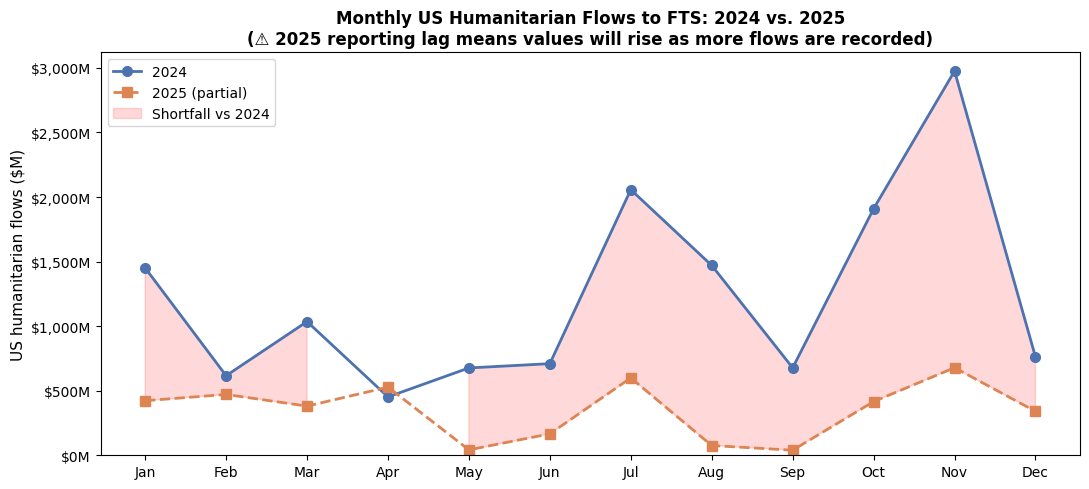

Saved → /Users/pauldelor/Documents/Rebelga/who-fills-the-gap/output/charts/fts_us_monthly_2024_vs_2025.png


In [17]:
# ── Chart: line — monthly US flows 2024 vs 2025 ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

month_labels = [lbl for (_, lbl) in pivot.index]
x = range(len(month_labels))

ax.plot(x, pivot[2024].values / 1e6, "o-", color="#4C72B0", linewidth=2,
        markersize=7, label="2024")
ax.plot(x, pivot[2025].values / 1e6, "s--", color="#DD8452", linewidth=2,
        markersize=7, label="2025 (partial)")

# Shade the gap between 2024 and 2025 to make the deficit visible
ax.fill_between(x, pivot[2024].values / 1e6, pivot[2025].values / 1e6,
                where=(pivot[2024].values > pivot[2025].values),
                alpha=0.15, color="red", label="Shortfall vs 2024")

# Mark the freeze order
if 0 in [m for (m, _) in pivot.index]:
    jan_idx = [i for i, (m, _) in enumerate(pivot.index) if m == 1]
    if jan_idx:
        ax.axvline(jan_idx[0], color="red", linestyle=":", linewidth=1.5, alpha=0.7)
        ax.text(jan_idx[0] + 0.05, ax.get_ylim()[1] * 0.95,
                "EO freeze\nJan 20", fontsize=8, color="red", va="top")

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel("US humanitarian flows ($M)", fontsize=11)
ax.set_title("Monthly US Humanitarian Flows to FTS: 2024 vs. 2025\n"
             "(⚠ 2025 reporting lag means values will rise as more flows are recorded)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))
ax.set_ylim(bottom=0)

plt.tight_layout()
chart_path = CHART_DIR / "fts_us_monthly_2024_vs_2025.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {chart_path}")

## 11 — Gap-filler candidates: which non-US donors are growing?

"Who fills the gap?" is the central question. Here we identify donors that:
1. Were significant contributors in 2022–2023 (so they have capacity)
2. Showed year-on-year growth from 2022 → 2023 → 2024 (so they are trending up)
3. Are not the US

These are the most plausible candidates to absorb part of the US shortfall — either
through deliberate policy decisions (e.g., EU emergency funding pledges) or structural
increases in their aid programmes.

In [18]:
NON_US_YEARS = [2022, 2023, 2024]
MIN_CONTRIBUTION = 50e6  # must have contributed at least $50M in at least one year

# Sum per donor × year, excluding US entities
donor_year = (
    df[~df["is_us"] & df["source_org"].notna() & df["year"].isin(NON_US_YEARS)]
    .groupby(["source_org", "year"])["amount_usd"]
    .sum()
    .unstack(fill_value=0)
)

# Only keep donors with at least $50M in any of the three years
donor_year = donor_year[donor_year.max(axis=1) >= MIN_CONTRIBUTION]

# Year-on-year growth rates
donor_year["growth_22_23"] = ((donor_year[2023] - donor_year[2022]) / donor_year[2022].replace(0, float("nan")) * 100).round(1)
donor_year["growth_23_24"] = ((donor_year[2024] - donor_year[2023]) / donor_year[2023].replace(0, float("nan")) * 100).round(1)

# Rank by 2024 funding — shows who is currently biggest
donor_year = donor_year.sort_values(2024, ascending=False).head(20)

print("Top 20 non-US donors (2024) with year-on-year growth:\n")
print(f"{'Organisation':<50} {'2022 ($M)':>10} {'2023 ($M)':>10} {'2024 ($M)':>10} {'22→23':>8} {'23→24':>8}")
print("-" * 102)
for org, row in donor_year.iterrows():
    g1 = f"{row['growth_22_23']:+.1f}%" if not pd.isna(row["growth_22_23"]) else "N/A"
    g2 = f"{row['growth_23_24']:+.1f}%" if not pd.isna(row["growth_23_24"]) else "N/A"
    marker = " ▲" if (not pd.isna(row["growth_23_24"]) and row["growth_23_24"] > 10) else ""
    print(f"{org:<50} {row[2022]/1e6:>10,.0f} {row[2023]/1e6:>10,.0f} {row[2024]/1e6:>10,.0f} {g1:>8} {g2:>8}{marker}")

print("\n▲ = grew >10% from 2023→2024 (potential gap-fillers)")

Top 20 non-US donors (2024) with year-on-year growth:

Organisation                                        2022 ($M)  2023 ($M)  2024 ($M)    22→23    23→24
------------------------------------------------------------------------------------------------------
European Commission's Humanitarian Aid and Civil Protection Department      4,300      3,968      3,822    -7.7%    -3.7%
Germany, Government of                                  6,616      5,088      3,176   -23.1%   -37.6%
United Kingdom, Government of                           1,593      1,559      2,702    -2.1%   +73.3% ▲
Japan, Government of                                    1,792      1,507      2,151   -15.9%   +42.7% ▲
Saudi Arabia (Kingdom of), Government of                1,714      2,141      1,923   +24.9%   -10.2%
Sweden, Government of                                   1,027      1,207      1,308   +17.5%    +8.4%
United Arab Emirates, Government of                       480        971      1,210  +102.2%   +24.5% ▲


## 12 — Key findings summary

Run this cell last to get a consolidated narrative summary of what the data shows.
These bullet points feed directly into `methodology.md` and the article draft.

In [19]:
print("=" * 65)
print("KEY FINDINGS — OCHA FTS HUMANITARIAN FLOWS 2018–2025")
print("=" * 65)

total_all = df["amount_usd"].sum()
total_us = df[df["is_us"]]["amount_usd"].sum()
us_share_all = total_us / total_all * 100

us_2024_total = df[(df["year"] == 2024) & df["is_us"]]["amount_usd"].sum()
all_2024_total = df[df["year"] == 2024]["amount_usd"].sum()
us_share_2024 = us_2024_total / all_2024_total * 100

# Count countries with >40% US dependency (using 2024, min $10M)
extreme_dep = country_dep[
    (country_dep["us_pct"] > 40) & (country_dep["total_usd"] >= 10e6)
]

print(f"""
Scale of the data
─────────────────
• {len(df):,} individual aid flows recorded 2018–2025
• ${total_all/1e9:.1f}B total humanitarian funding tracked
• ${total_us/1e9:.1f}B from the United States ({us_share_all:.1f}% of total)

US position in 2024 (last full year before freeze)
────────────────────────────────────────────────────
• US contributed ${us_2024_total/1e9:.2f}B out of ${all_2024_total/1e9:.2f}B total ({us_share_2024:.1f}%)
• {len(extreme_dep)} countries received >40% of their humanitarian inflows from the US
  (minimum $10M threshold)

2025 early signal (reported flows as of {today.strftime('%B %d, %Y')})
────────────────────────────────────────────────────────────────────────────
• US 2025 YTD: ${us_2025/1e9:.2f}B vs ${us_2024/1e9:.2f}B same period 2024
  ({(us_2025 - us_2024) / us_2024 * 100:+.1f}%)
• All-donor 2025 YTD: ${all_2025/1e9:.2f}B vs ${all_2024/1e9:.2f}B same period
  ({(all_2025 - all_2024) / all_2024 * 100:+.1f}%)
• NOTE: 2025 figures will rise as reporting catches up — these are floors.

Methodological caveats
───────────────────────
• FTS is voluntary self-reporting; some donors (especially bilaterals)
  under-report or report late.
• "Commitment" ≠ "paid" — we include both (standard FTS practice).
• In-kind contributions included but have inconsistent USD valuation.
• Double-counting risk: pooled fund contributions may appear twice
  (once when a government contributes to a fund, once when the fund
  disburses to an implementer).
• 2025 data is partial: reporting lag is 2–6 months for many donors.
""")
print("=" * 65)

KEY FINDINGS — OCHA FTS HUMANITARIAN FLOWS 2018–2025



Scale of the data
─────────────────
• 218,558 individual aid flows recorded 2018–2025
• $329.1B total humanitarian funding tracked
• $90.6B from the United States (27.5% of total)

US position in 2024 (last full year before freeze)
────────────────────────────────────────────────────
• US contributed $14.79B out of $44.51B total (33.2%)
• 42 countries received >40% of their humanitarian inflows from the US
  (minimum $10M threshold)

2025 early signal (reported flows as of May 08, 2026)
────────────────────────────────────────────────────────────────────────────
• US 2025 YTD: $1.65B vs $4.39B same period 2024
  (-62.3%)
• All-donor 2025 YTD: $8.19B vs $14.61B same period
  (-44.0%)
• NOTE: 2025 figures will rise as reporting catches up — these are floors.

Methodological caveats
───────────────────────
• FTS is voluntary self-reporting; some donors (especially bilaterals)
  under-report or report late.
• "Commitment" ≠ "paid" — we include both (standard FTS practice).
• In-kind contr